## Hierarchical vs Sequential 프로세스 비교

멀티 에이전트 시스템에서 sub-agent들을 **어떤 순서로 실행할지 결정하는 방식(process)**은 크게 두 가지로 나뉜다.

- **Sequential (순차) 프로세스**: `writer → editor → fact_checker` 처럼 실행 순서가 미리 고정되어 있다. 각 agent는 정확히 한 번씩만 실행되고, 앞 단계로 되돌아가지 않는다. 흐름이 단순하고 비용·지연시간을 예측하기 쉽지만, 뒤 단계에서 문제가 발견돼도 스스로 고치지 못한다.
- **Hierarchical (계층적) 프로세스**: manager(supervisor) 에이전트가 매 단계마다 지금까지의 결과를 보고 **다음에 어떤 sub-agent를 실행할지, 혹은 끝낼지**를 동적으로 결정한다. 문제가 발견되면 관련 sub-agent로 되돌아가는 루프가 가능하다. 결과 품질은 높아지지만 호출 횟수와 지연시간이 상황에 따라 달라진다.

```
[Sequential]                              [Hierarchical]

writer → editor → fact_checker → 종료          ┌─────────┐
  (고정된 순서, 되돌아가지 않음)         ┌──────►│ manager │◄──────┐
                                        │      └────┬────┘       │
                                        │           │(다음 agent 또는 종료 결정)
                                     writer ◄────────┼────────► editor
                                        ▲                          │
                                        └──────── fact_checker ◄───┘
                                             (필요하면 writer로 되돌아감)
```

이 노트북에서는 **동일한 sub-agent 3종(writer, editor, fact_checker)**을 재사용해서 두 프로세스를 각각 LangGraph로 구현하고, 같은 입력으로 실행해 차이를 비교한다. sub-agent 구현 자체는 바뀌지 않고, 이들을 **어떻게 조율(orchestrate)하는가**만 다르다는 점이 핵심이다.

In [1]:
import os
from dotenv import load_dotenv

# .env 파일에서 API 키 불러오기
load_dotenv("C:/env/.env")

True

### [0] 사전 준비: LLM, 상태(State), 참고 사실

In [2]:
from typing import List, Literal, TypedDict

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [3]:
class State(TypedDict):
    topic: str              # 소개 글을 작성할 대상
    draft: str               # 현재 초안
    feedback: List[str]      # editor/fact_checker가 남긴, 아직 반영되지 않은 피드백
    editor_approved: bool    # editor가 현재 draft를 승인했는지
    fact_check_ok: bool      # fact_checker가 현재 draft를 통과시켰는지
    revision_count: int      # manager가 재작업을 지시한 횟수 (hierarchical 전용, 무한 루프 방지)
    next_agent: str          # manager가 결정한 다음 실행 대상 (hierarchical 전용)
    history: List[str]       # 실행된 노드 순서 기록 (비교용)
    final: str                # 최종 결과물


# writer/fact_checker가 근거로 삼을 참고 사실 (fact_checker가 draft와 대조 검증한다)
NEURONCHIP_FACTS = [
    "뉴런칩은 2021년에 설립된 AI 반도체 스타트업이다.",
    "뉴런칩은 저전력 NPU(Neural Processing Unit) 설계를 전문으로 한다.",
    "뉴런칩은 2024년 시리즈 B 라운드에서 250억원을 유치했다.",
    "뉴런칩의 주요 고객사는 국내 자율주행 스타트업들이다.",
]

### [1] 공용 Sub-agent 구현

`writer`, `editor`, `fact_checker` 세 노드는 sequential/hierarchical 그래프 모두에서 그대로 재사용한다.

- `writer`: 참고 사실과 (있다면) 피드백을 반영해 초안을 (재)작성한다. 새로 쓸 때마다 `editor_approved`, `fact_check_ok`를 초기화해서 재검토가 필요함을 표시한다.
- `editor`: 문체·가독성을 다듬고, 충분히 매끄러우면 승인(`approved=True`)한다.
- `fact_checker`: draft의 주장이 참고 사실과 일치하는지 검증하고, 근거 없는 주장이 있으면 지적한다.

In [4]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

writer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "너는 스타트업 소개 글을 쓰는 writer 에이전트다. 주어진 참고 사실만 근거로 2~3문장의 소개 글을 작성하라. "
            "이전 피드백이 있다면 반드시 반영해서 다시 작성하라.",
        ),
        (
            "human",
            "소개 대상: {topic}\n참고 사실:\n{facts}\n\n이전 피드백:\n{feedback}\n\n이전 초안:\n{draft}",
        ),
    ]
)


def writer_node(state: State) -> dict:
    response = llm.invoke(
        writer_prompt.format_messages(
            topic=state["topic"],
            facts="\n".join(f"- {f}" for f in NEURONCHIP_FACTS),
            feedback="; ".join(state["feedback"]) if state["feedback"] else "없음",
            draft=state["draft"] or "(초안 없음)",
        )
    )
    print("[Writer] 새 초안 작성 완료")
    return {
        "draft": response.content,
        "feedback": [],
        "editor_approved": False,
        "fact_check_ok": False,
        "history": state["history"] + ["writer"],
    }


class EditResult(BaseModel):
    edited_draft: str = Field(description="문체를 다듬은 draft")
    approved: bool = Field(description="이미 충분히 매끄러워 추가 수정이 필요 없으면 true")
    comment: str = Field(description="승인하지 않았다면 그 이유")


editor_llm = llm.with_structured_output(EditResult)
editor_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "너는 문체와 가독성을 다듬는 editor 에이전트다. draft의 사실 내용은 바꾸지 말고 자연스럽고 "
            "간결하게 다듬어라.",
        ),
        ("human", "{draft}"),
    ]
)


def editor_node(state: State) -> dict:
    result = editor_llm.invoke(editor_prompt.format_messages(draft=state["draft"]))
    print(f"[Editor] approved={result.approved} ({result.comment})")
    feedback = state["feedback"] if result.approved else state["feedback"] + [f"[editor] {result.comment}"]
    return {
        "draft": result.edited_draft,
        "editor_approved": result.approved,
        "feedback": feedback,
        "history": state["history"] + ["editor"],
    }


class FactCheckResult(BaseModel):
    ok: bool = Field(description="draft의 모든 주장이 참고 사실과 일치하면 true")
    issues: List[str] = Field(description="참고 사실과 어긋나거나 근거 없는 주장 목록")


fact_checker_llm = llm.with_structured_output(FactCheckResult)
fact_checker_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "너는 draft의 주장이 주어진 참고 사실과 일치하는지 검증하는 fact_checker 에이전트다. "
            "참고 사실에 없거나 모순되는 주장이 있으면 ok=false로, issues에 구체적으로 문제된 부분을 적어라. "
            "모두 일치하면 ok=true, issues는 빈 리스트로 반환하라.",
        ),
        ("human", "참고 사실:\n{facts}\n\n검증할 draft:\n{draft}"),
    ]
)


def fact_checker_node(state: State) -> dict:
    result = fact_checker_llm.invoke(
        fact_checker_prompt.format_messages(
            facts="\n".join(f"- {f}" for f in NEURONCHIP_FACTS), draft=state["draft"]
        )
    )
    print(f"[FactChecker] ok={result.ok} issues={result.issues}")
    feedback = (
        state["feedback"] if result.ok else state["feedback"] + [f"[fact_checker] {i}" for i in result.issues]
    )
    return {
        "fact_check_ok": result.ok,
        "feedback": feedback,
        "history": state["history"] + ["fact_checker"],
    }

### [2] Sequential 프로세스: 고정된 순서

`writer → editor → fact_checker → finalize` 순서가 코드에 고정되어 있다. fact_checker가 문제를 발견해도 writer에게 되돌아가는 경로 자체가 그래프에 존재하지 않는다.

In [5]:
from langgraph.graph import END, StateGraph


def finalize_node(state: State) -> dict:
    if state["feedback"]:
        print(f"[Finalize] 미해결 이슈가 남아 있지만 순차 프로세스는 되돌아가지 않는다: {state['feedback']}")
    else:
        print("[Finalize] 이슈 없이 완료")
    return {"final": state["draft"]}


seq_graph = StateGraph(State)
seq_graph.add_node("writer", writer_node)
seq_graph.add_node("editor", editor_node)
seq_graph.add_node("fact_checker", fact_checker_node)
seq_graph.add_node("finalize", finalize_node)

seq_graph.set_entry_point("writer")
seq_graph.add_edge("writer", "editor")
seq_graph.add_edge("editor", "fact_checker")
seq_graph.add_edge("fact_checker", "finalize")
seq_graph.add_edge("finalize", END)

sequential_app = seq_graph.compile()

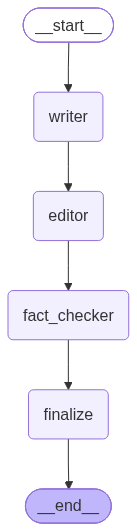

In [6]:
from IPython.display import Image, display

display(Image(sequential_app.get_graph().draw_mermaid_png()))

### [3] Hierarchical 프로세스: manager가 매 단계 결정

`manager` 노드가 구조화 출력(`Decision`)으로 다음 실행 대상(`writer`/`editor`/`fact_checker`/`finish`)을 고른다. 각 sub-agent는 실행 후 무조건 `manager`로 되돌아가므로, 문제가 남아있는 한 필요한 만큼 루프를 돌 수 있다. 무한 루프 방지를 위해 `revision_count`가 일정 횟수를 넘으면 강제로 종료시킨다.

In [7]:
MAX_REVISIONS = 4


class Decision(BaseModel):
    next: Literal["writer", "editor", "fact_checker", "finish"] = Field(
        description="다음에 실행할 sub-agent. 더 이상 수정이 필요 없으면 finish"
    )
    reason: str = Field(description="이 판단을 내린 이유")


manager_llm = llm.with_structured_output(Decision)
manager_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "너는 콘텐츠 제작 파이프라인을 감독하는 manager 에이전트다. 아래 규칙을 순서대로 확인해 "
            "다음에 실행할 sub-agent를 결정하라. 문제가 발견되면 정해진 순서와 상관없이 관련 agent로 "
            "되돌아갈 수 있다.\n\n"
            "1) 아직 초안이 없으면 writer\n"
            "2) 남아있는 피드백 중 [fact_checker]로 시작하는 항목이 있으면 writer (사실관계 수정)\n"
            "3) fact_checker를 아직 통과하지 못했다면 fact_checker\n"
            "4) 남아있는 피드백 중 [editor]로 시작하는 항목이 있으면 writer (문체 관련 재작성)\n"
            "5) editor가 아직 승인하지 않았다면 editor\n"
            "6) 모든 조건을 통과했다면 finish",
        ),
        (
            "human",
            "현재 상태\n- 초안 유무: {has_draft}\n- fact_checker 통과 여부: {fact_check_ok}\n"
            "- editor 승인 여부: {editor_approved}\n- 남은 피드백: {feedback}",
        ),
    ]
)


def manager_node(state: State) -> dict:
    if state["revision_count"] >= MAX_REVISIONS:
        print(f"[Manager] 재작업 한도({MAX_REVISIONS}회) 도달 -> 강제 종료")
        return {"next_agent": "finish", "final": state["draft"]}

    decision = manager_llm.invoke(
        manager_prompt.format_messages(
            has_draft="있음" if state["draft"] else "없음",
            fact_check_ok=state["fact_check_ok"],
            editor_approved=state["editor_approved"],
            feedback="; ".join(state["feedback"]) if state["feedback"] else "없음",
        )
    )
    print(f"[Manager] 다음 단계: {decision.next} (이유: {decision.reason})")

    if decision.next == "finish":
        return {"next_agent": "finish", "final": state["draft"]}
    return {"next_agent": decision.next, "revision_count": state["revision_count"] + 1}


def route_from_manager(state: State) -> str:
    return state["next_agent"]


hier_graph = StateGraph(State)
hier_graph.add_node("manager", manager_node)
hier_graph.add_node("writer", writer_node)
hier_graph.add_node("editor", editor_node)
hier_graph.add_node("fact_checker", fact_checker_node)

hier_graph.set_entry_point("manager")
hier_graph.add_conditional_edges(
    "manager",
    route_from_manager,
    {"writer": "writer", "editor": "editor", "fact_checker": "fact_checker", "finish": END},
)
# 각 sub-agent는 실행 후 항상 manager에게 판단을 되돌려준다
hier_graph.add_edge("writer", "manager")
hier_graph.add_edge("editor", "manager")
hier_graph.add_edge("fact_checker", "manager")

hierarchical_app = hier_graph.compile()

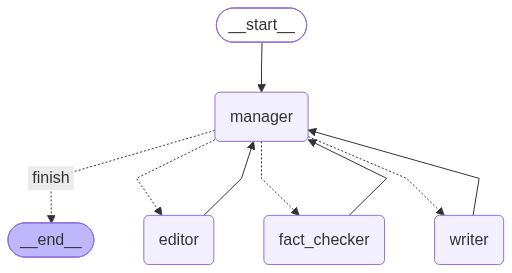

In [8]:
display(Image(hierarchical_app.get_graph().draw_mermaid_png()))

### [4] 동일 입력으로 실행 비교

In [25]:
def initial_state(topic: str) -> State:
    return {
        "topic": topic,
        "draft": "",
        "feedback": [],
        "editor_approved": False,
        "fact_check_ok": False,
        "revision_count": 0,
        "next_agent": "",
        "history": [],
        "final": "",
    }


topic = "국내 AI 반도체 스타트업 '뉴런칩'"

print("########## Sequential ##########")
seq_result = sequential_app.invoke(initial_state(topic))

print("\n########## Hierarchical ##########")
hier_result = hierarchical_app.invoke(initial_state(topic), config={"recursion_limit": 50})

########## Sequential ##########
[Writer] 새 초안 작성 완료
[Editor] approved=True ()
[FactChecker] ok=True issues=[]
[Finalize] 이슈 없이 완료

########## Hierarchical ##########
[Manager] 다음 단계: writer (이유: 아직 초안이 없기 때문에 writer에게 진행해야 함.)
[Writer] 새 초안 작성 완료
[Manager] 다음 단계: fact_checker (이유: fact_checker를 아직 통과하지 못했기 때문에 fact_checker로 진행해야 합니다.)
[FactChecker] ok=True issues=[]
[Manager] 다음 단계: editor (이유: editor가 아직 승인하지 않았기 때문에 editor에게 진행해야 함.)
[Editor] approved=True ()
[Manager] 다음 단계: finish (이유: 모든 조건을 통과했으므로 최종 단계로 진행할 수 있습니다.)


In [26]:
print("=== Sequential ===")
print(f"실행 순서: {' -> '.join(seq_result['history'])}")
print(f"총 노드 실행 횟수: {len(seq_result['history'])}")
print(f"남은 미해결 피드백: {seq_result['feedback']}")
print(f"최종 결과:\n{seq_result['final']}")

print("\n=== Hierarchical ===")
print(f"실행 순서: {' -> '.join(hier_result['history'])}")
print(f"총 노드 실행 횟수: {len(hier_result['history'])} (manager 판단 횟수는 별도)")
print(f"남은 미해결 피드백: {hier_result['feedback']}")
print(f"최종 결과:\n{hier_result['final']}")

=== Sequential ===
실행 순서: writer -> editor -> fact_checker
총 노드 실행 횟수: 3
남은 미해결 피드백: []
최종 결과:
뉴런칩은 2021년에 설립된 국내 AI 반도체 스타트업으로, 저전력 NPU(Neural Processing Unit) 설계를 전문으로 합니다. 2024년에는 시리즈 B 라운드에서 250억원을 유치하며 성장세를 이어가고 있으며, 주요 고객으로는 국내 자율주행 스타트업들이 있습니다. 뉴런칩은 혁신적인 기술로 AI 반도체 시장에서의 입지를 확고히 하고 있습니다.

=== Hierarchical ===
실행 순서: writer -> fact_checker -> editor
총 노드 실행 횟수: 3 (manager 판단 횟수는 별도)
남은 미해결 피드백: []
최종 결과:
뉴런칩은 2021년에 설립된 국내 AI 반도체 스타트업으로, 저전력 NPU(Neural Processing Unit) 설계를 전문으로 합니다. 2024년에는 시리즈 B 라운드에서 250억원을 유치하며 성장세를 이어가고 있으며, 주요 고객으로는 국내 자율주행 스타트업들이 있습니다. 뉴런칩은 혁신적인 기술로 AI 반도체 시장에서의 입지를 확고히 하고 있습니다.


### 정리

| | Sequential | Hierarchical |
|---|---|---|
| 실행 순서 | 고정 (`writer → editor → fact_checker`) | manager가 매 단계 동적으로 결정 |
| 문제 발견 시 대응 | 되돌아가지 못하고 그대로 종료 | 관련 sub-agent로 되돌아가 재작업 |
| 호출 횟수·지연시간 | 항상 일정, 예측 가능 | 상황에 따라 가변적 (루프 발생 가능) |
| 결과 품질 보장 | 낮음 (마지막 단계 이슈를 못 고침) | 높음 (manager의 통과 기준을 만족해야 종료) |
| 구현 복잡도 | 낮음 | 높음 (manager 프롬프트 설계, 무한 루프 방지 필요) |
| 적합한 경우 | 단계별 실패 위험이 낮고 비용·지연시간이 중요한 경우 | 품질 검증이 중요하고 재작업 비용을 감수할 수 있는 경우 |

두 프로세스 모두 같은 `writer`/`editor`/`fact_checker` sub-agent를 그대로 재사용했다. 즉 **sub-agent 설계와 프로세스(orchestration) 설계는 독립적인 관심사**이며, 요구사항에 따라 동일한 sub-agent 집합 위에 다른 프로세스를 자유롭게 얹을 수 있다. 실무에서는 두 방식을 혼합해서 쓰기도 한다 — 예를 들어 큰 틀은 sequential로 고정하되, 품질이 중요한 특정 단계만 hierarchical 서브그래프로 감싸는 식이다.